In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pickle

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])  # Convert text data to numerical features
y = data[target_column]  # Target labels

# Step 2: Split the dataset into training and testing sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the XGBoost model
print("Training XGBoost Model...")
dtrain = xgb.DMatrix(X_train_tfidf, label=y_train)  # Convert data to DMatrix format for XGBoost
dtest = xgb.DMatrix(X_test_tfidf, label=y_test)

params = {
    'objective': 'multi:softmax',  # For multi-class classification
    'eval_metric': 'mlogloss',      # Log loss metric for multi-class classification
    'num_class': len(y.unique()),  # Number of classes
    'max_depth': 6,                 # Maximum depth of the trees
    'learning_rate': 0.1,           # Step size shrinkage
    'subsample': 0.8,               # Fraction of data to train on
    'colsample_bytree': 0.8,        # Fraction of features for each tree
    'nthread': 4                    # Number of threads for parallelism
}

# Train the model
num_round = 100  # Number of boosting rounds
xgb_model = xgb.train(params, dtrain, num_round)

# Step 4: Save the trained XGBoost model
model_path = r"C:\Users\PC\Downloads\xgboost_model.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"Trained XGBoost model saved to {model_path}")

# Step 5: Evaluate the XGBoost model
y_pred_xgb = xgb_model.predict(dtest)

# Convert predictions to integers if needed
y_pred_xgb = y_pred_xgb.astype(int)

# Calculate accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')  # Use 'weighted' for multi-class
recall = recall_score(y_test, y_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"XGBoost Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-Score: {f1 * 100:.2f}%")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb))


Training XGBoost Model...
Trained XGBoost model saved to C:\Users\PC\Downloads\xgboost_model.pkl
XGBoost Accuracy: 89.31%
Precision: 89.51%
Recall: 89.31%
F1-Score: 89.30%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     23238
           1       0.92      0.86      0.89     23171

    accuracy                           0.89     46409
   macro avg       0.90      0.89      0.89     46409
weighted avg       0.90      0.89      0.89     46409



Confusion Matrix:
[[21573  1665]
 [ 3294 19877]]


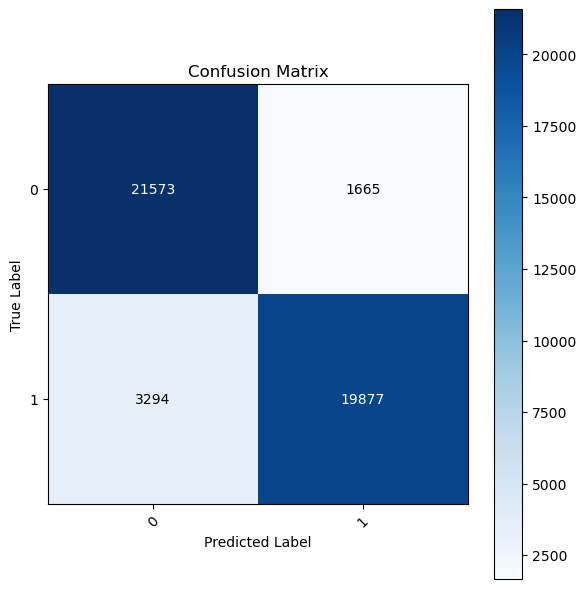

In [10]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the rest of the code for data preparation and model training is already done

# Step 5: Evaluate the XGBoost model
y_pred_xgb = xgb_model.predict(dtest)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Display confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = np.unique(y_test)  # Unique classes
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add labels to cells
thresh = cm.max() / 2.0
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()


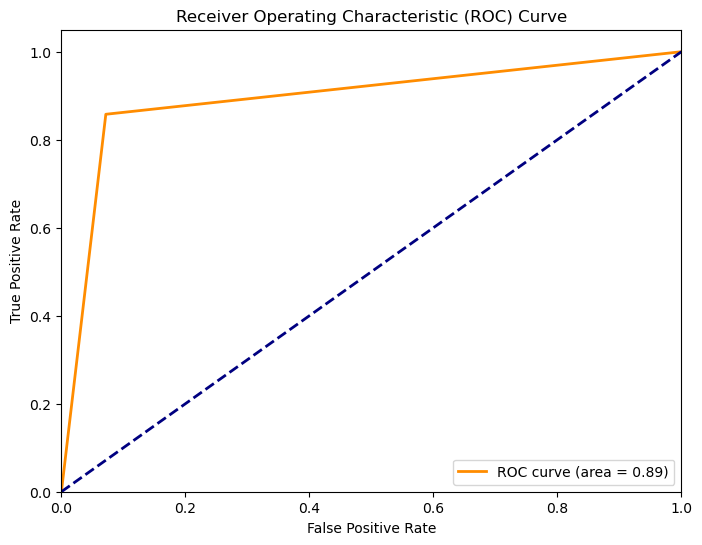

In [11]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ensure your labels are binary (e.g., 0 or 1)
if len(np.unique(y)) == 2:
    # Get decision function or probabilities for XGBoost
    y_prob = xgb_model.predict(dtest, output_margin=False)  # This returns probabilities for binary classification

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
else:
    print("ROC curve is only available for binary classification.")


XGBoost MAE: 0.1069, MSE: 0.1069, RMSE: 0.3269


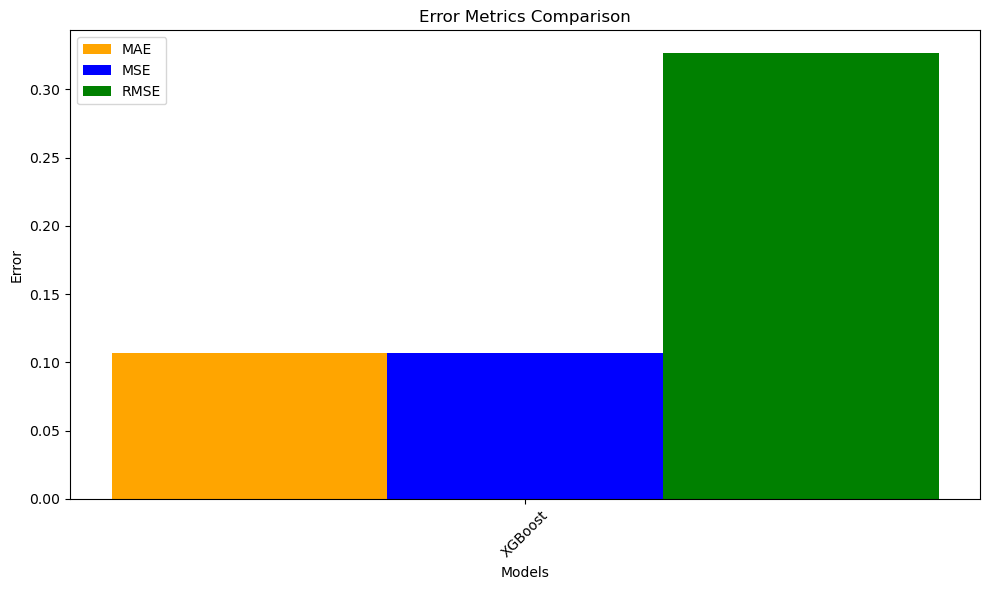

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store error metrics
error_metrics = {}

# For the XGBoost model (assuming it's already trained and available)
model_name = "XGBoost"  # You can change this if you have multiple models

# Predict on the test set
y_pred_xgb = xgb_model.predict(dtest)

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

# Store error metrics
error_metrics[model_name] = {"MAE": mae, "MSE": mse, "RMSE": rmse}

# Print metrics
print(f"{model_name} MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


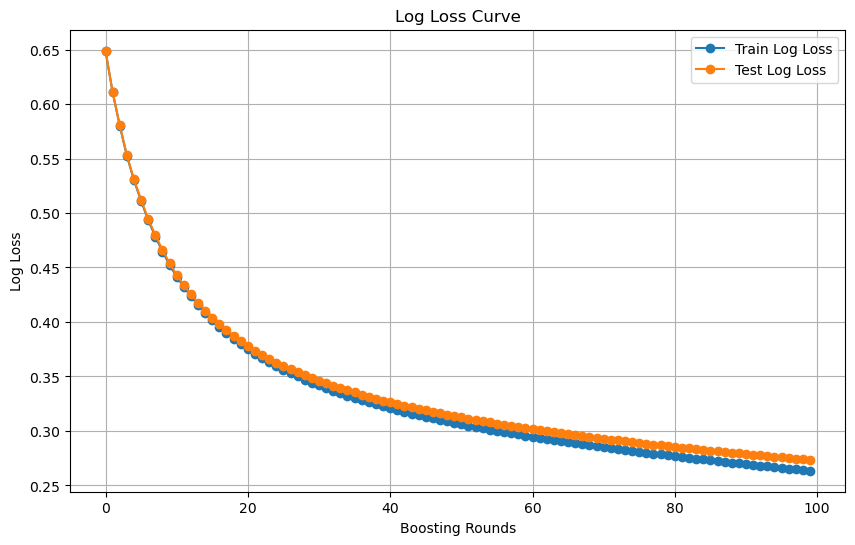

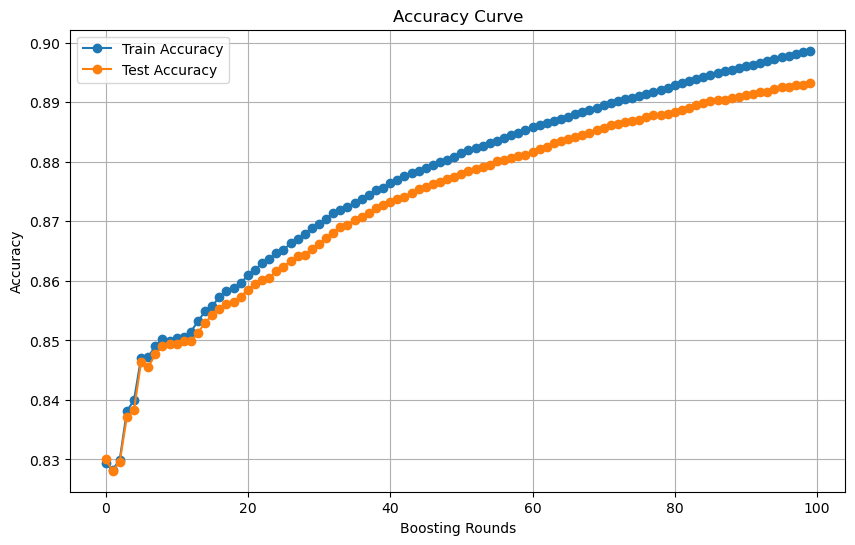

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])
y = data[target_column]

# Step 2: Split the dataset into training and testing sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the XGBoost model with evals_result tracking
dtrain = xgb.DMatrix(X_train_tfidf, label=y_train)
dtest = xgb.DMatrix(X_test_tfidf, label=y_test)

params = {
    'objective': 'multi:softmax',
    'eval_metric': ['mlogloss', 'merror'],
    'num_class': len(y.unique()),
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'nthread': 4
}

evals_result = {}
xgb_model = xgb.train(
    params, 
    dtrain, 
    num_boost_round=100, 
    evals=[(dtrain, 'train'), (dtest, 'test')], 
    evals_result=evals_result, 
    verbose_eval=False
)

# Step 4: Plot accuracy and loss curves
# Extract metrics
train_logloss = evals_result['train']['mlogloss']
test_logloss = evals_result['test']['mlogloss']
train_accuracy = [1 - x for x in evals_result['train']['merror']]
test_accuracy = [1 - x for x in evals_result['test']['merror']]

# Plot log loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_logloss, label='Train Log Loss', marker='o')
plt.plot(test_logloss, label='Test Log Loss', marker='o')
plt.title("Log Loss Curve")
plt.xlabel("Boosting Rounds")
plt.ylabel("Log Loss")
plt.legend()
plt.grid()
plt.show()

# Plot accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy, label='Train Accuracy', marker='o')
plt.plot(test_accuracy, label='Test Accuracy', marker='o')
plt.title("Accuracy Curve")
plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()
